---
title: "Intro to EDA"
date: last-modified
toc: true
format:
  html: default
  ipynb: default
---


Exploratory data analysis, or EDA, is a standard practice prior to any data manipulation and analysis.

Recall that data engineering is primarily about data preparation to *serve* smooth and effective data analysis.  Exploratory data analysis generally refers to the step of understanding the data:  

- **summarizing characteristics of raw data**
- **visualizing data (single and multiple variables)**
- identifying missing data
- identifying outliers

This document primarily deals with the first two items.  

## Goals
In the **exploratory** phase, these are for people behind the scenes to see.  

The main goals here are:

- capture main message
- (relatively) quick exploration across many summaries (including plots)
- *not* intended for a client or presentation

What does this translate to, technically?

- each summary should have meaningful information
- **label** your plots

## Data summary
As a starting point, simply looking at the data is worth the while.  Some common questions to consider are the following:  


1. General dataset info: size, dtypes  
2. Missing values?  
3. Duplicate data?  
4. Continuous variables  
5. Categorical variables  
6. Bivariate relationships  
7. Potential data quality issues, e.g., inconsistency, special NA characters

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

|![sns](../img/sns.jpg)|
|:---:|
|[The origin of sns.](https://seaborn.pydata.org/faq.html#why-is-seaborn-imported-as-sns)|

## Earthquake dataset

[Source Link](https://open.canada.ca/data/en/dataset/2c3672b6-4c17-4ff5-9861-29e2dd6d03b3/resource/9cfea46f-561a-440f-9d17-fed3557fc7b5)

In [4]:
# load and save a copy of the earthquake dataset
earthquake = pd.read_csv('https://raw.githubusercontent.com/mosesyhc/de300-2026wi/refs/heads/main/datasets/Canadian-Earthquakes-2010-2019.csv')

In [94]:
# take a glimpse of the data
earthquake.head()
earthquake.tail()

,magnitude_codelist,magnitude,magnitude_type,place,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom
date,,,,,,,,,,
2016-08-09 03:24:27+00:00,2,2.6,Mw,123 km W of Gold R.,10.000000,49.570000,-127.806000,30135,-127.806416,49.569905
2014-10-20 11:37:12+00:00,2,2.9,ML,131 km ESE of Juneau,10.000000,57.512001,-132.757004,21295,-132.757420,57.512304
2012-10-30 15:14:19+00:00,2,2.5,ML,95 km SSW of Sandspit,30.000000,52.435001,-132.272003,12538,-132.271618,52.434805
2018-08-13 16:23:42+00:00,<2,1.4,ML,59 SSW of Sandspit,21.299999,52.723999,-131.960007,38625,-131.960018,52.724005
2010-11-10 08:48:27+00:00,<2,1.9,ML,40 km NNE of Yakutat,10.000000,59.639999,-139.292999,4789,-139.292622,59.640003


In [6]:
# view a summary of the full data
earthquake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44561 entries, 0 to 44560
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   magnitude_codelist  44561 non-null  object 
 1   magnitude           44561 non-null  float64
 2   magnitude_type      44462 non-null  object 
 3   date                44561 non-null  object 
 4   place               44561 non-null  object 
 5   depth               44561 non-null  float64
 6   latitude            44561 non-null  float64
 7   longitude           44561 non-null  float64
 8   OBJECTID            44561 non-null  int64  
 9   longitude_geom      44561 non-null  float64
 10  latitude_geom       44561 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 3.7+ MB


In [7]:
# checks for duplicates (also ask if duplicates make sense)
# iloc : specific column or row number we are looking for
# .loc : names of the rows and columns, column indec
earthquake[earthquake.duplicated()]

,magnitude_codelist,magnitude,magnitude_type,date,place,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom


In [8]:
# duplicates


In [9]:
# a quick numerical summary
# include all to include non-numerical columns
earthquake.describe(include='all')

,magnitude_codelist,magnitude,magnitude_type,date,place,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom
count,44561,44561.000000,44462,44561,44561,44561.000000,44561.000000,44561.000000,44561.000000,44561.000000,44561.000000
unique,6,NaN,7,44481,18639,NaN,NaN,NaN,NaN,NaN,NaN
top,<2,NaN,ML,2018-07-02T04:08:13+0000,CHARLEVOIX SEISMIC ZONE,NaN,NaN,NaN,NaN,NaN,NaN
freq,19764,NaN,29509,3,1250,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.134070,NaN,NaN,NaN,12.852194,53.351863,-118.953322,22281.000000,-118.953299,53.351830
std,NaN,0.828096,NaN,NaN,NaN,9.963145,6.214464,23.696484,12863.797009,23.696493,6.214465
min,NaN,-1.400000,NaN,NaN,NaN,-0.500000,40.808998,-148.811005,1.000000,-148.810526,40.808509
25%,NaN,1.600000,NaN,NaN,NaN,5.000000,49.169998,-132.427994,11141.000000,-132.427618,49.170009
50%,NaN,2.100000,NaN,NaN,NaN,10.000000,52.137001,-129.671997,22281.000000,-129.672016,52.136507
75%,NaN,2.700000,NaN,NaN,NaN,18.000000,56.514999,-121.947998,33421.000000,-121.948318,56.515206


In [10]:
# checks for possible statistical assumption(s)
import scipy.stats as sps
sps.normaltest(earthquake['magnitude'])

NormaltestResult(statistic=np.float64(1597.6658124732553), pvalue=np.float64(0.0))

In [11]:
# extract only numeric variables
earthquake_num = earthquake.select_dtypes('number')

In [12]:
earthquake_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44561 entries, 0 to 44560
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   magnitude       44561 non-null  float64
 1   depth           44561 non-null  float64
 2   latitude        44561 non-null  float64
 3   longitude       44561 non-null  float64
 4   OBJECTID        44561 non-null  int64  
 5   longitude_geom  44561 non-null  float64
 6   latitude_geom   44561 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 2.4 MB


In [13]:
# for example, normality test
sps.normaltest(earthquake_num)

NormaltestResult(statistic=array([ 1597.66581247, 15302.56967363,  9387.86913782,  8551.48250207,
       39401.07756051,  8551.48413702,  9387.85609679]), pvalue=array([0., 0., 0., 0., 0., 0., 0.]))

In [14]:
# for example, another normality test
# only works for one column
sps.shapiro(earthquake['magnitude'])

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 44561.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.9877396508026011), pvalue=np.float64(1.179774985585813e-49))

In [15]:
# pairwise correlation
earthquake_num.corr()

,magnitude,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom
magnitude,1.000000,-0.127958,0.196699,-0.110731,-0.006523,-0.110731,0.196699
depth,-0.127958,1.000000,-0.107744,-0.005796,-0.103983,-0.005796,-0.107744
latitude,0.196699,-0.107744,1.000000,-0.266265,-0.000391,-0.266265,1.000000
longitude,-0.110731,-0.005796,-0.266265,1.000000,0.049094,1.000000,-0.266265
OBJECTID,-0.006523,-0.103983,-0.000391,0.049094,1.000000,0.049093,-0.000390
longitude_geom,-0.110731,-0.005796,-0.266265,1.000000,0.049093,1.000000,-0.266265
latitude_geom,0.196699,-0.107744,1.000000,-0.266265,-0.000390,-0.266265,1.000000


## Data visualization

In [28]:
sns.set(context='talk', style='ticks')  # simply for aesthetics
sns.set_palette('magma')
%matplotlib inline

#sampling during EDA for large datasets
earthquake = earthquake.sample(n=500)  # (if too slow) for illustration purposes

<Axes: ylabel='Frequency'>

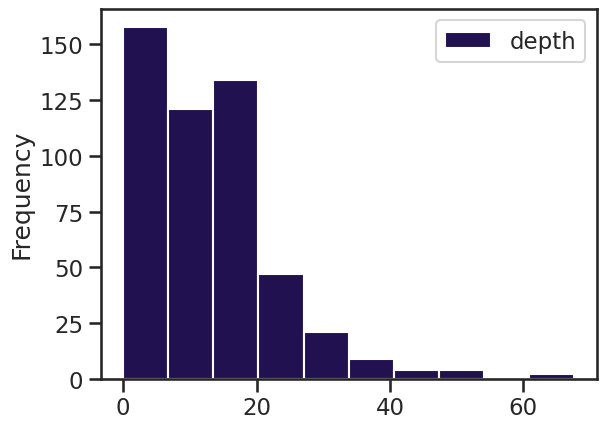

In [29]:
# histogram for continuous variables using pandas built-in plots
earthquake.plot.hist(column='depth')

<Axes: xlabel='depth', ylabel='Probability'>

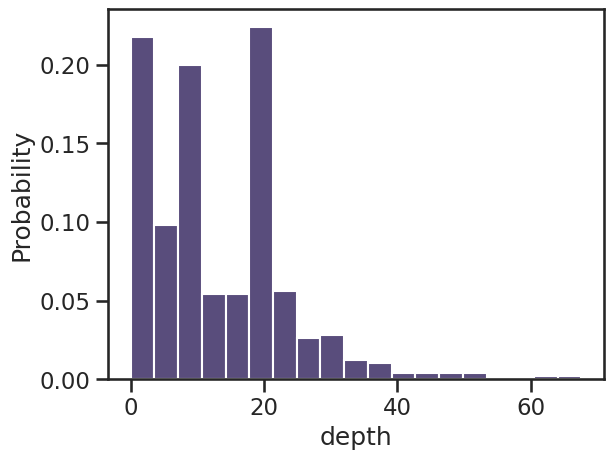

In [30]:
# relative frequency? ...
sns.histplot(x='depth', data=earthquake, stat='probability')

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 32225 to 4788
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   magnitude_codelist  500 non-null    object 
 1   magnitude           500 non-null    float64
 2   magnitude_type      499 non-null    object 
 3   date                500 non-null    object 
 4   place               500 non-null    object 
 5   depth               500 non-null    float64
 6   latitude            500 non-null    float64
 7   longitude           500 non-null    float64
 8   OBJECTID            500 non-null    int64  
 9   longitude_geom      500 non-null    float64
 10  latitude_geom       500 non-null    float64
dtypes: float64(6), int64(1), object(4)
memory usage: 46.9+ KB


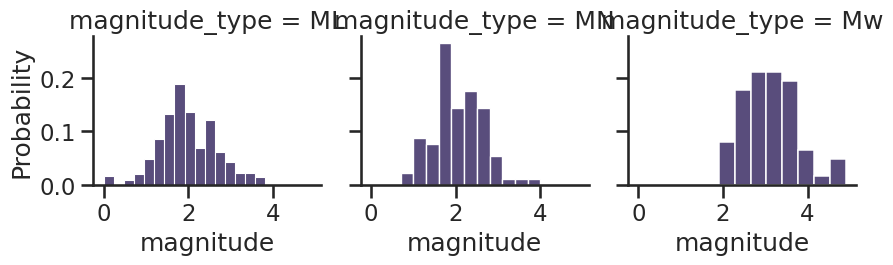

In [72]:
# histogram of masses by group
earthquake.info()
g=sns.FacetGrid(earthquake,col='magnitude_type')
g.map(sns.histplot,'magnitude',stat='probability')

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the violinplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


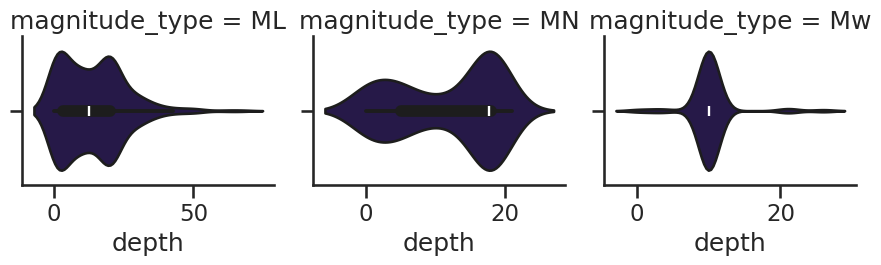

In [73]:
# other types of plots
g=sns.FacetGrid(earthquake,col='magnitude_type',sharex=False)
g.map(sns.violinplot,'depth')

<Axes: xlabel='magnitude_type', ylabel='count'>

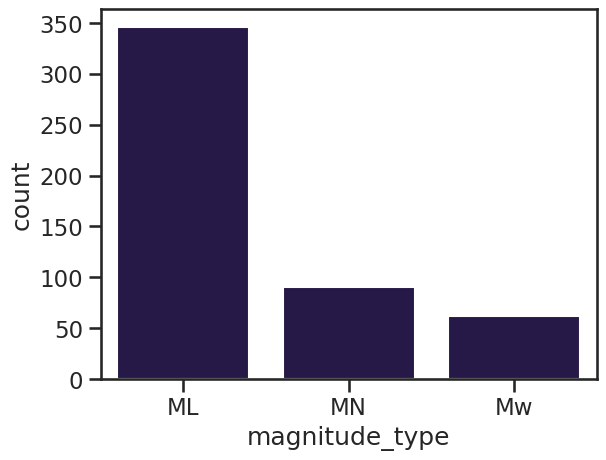

In [33]:
# counts for categorical variables
sns.countplot(x='magnitude_type',data=earthquake)

<Axes: xlabel='magnitude_type', ylabel='depth'>

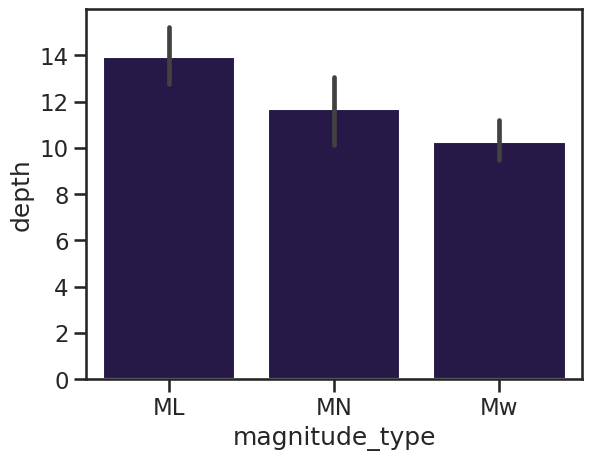

In [34]:
# barplots by group
sns.barplot(x='magnitude_type', y='depth',data=earthquake)

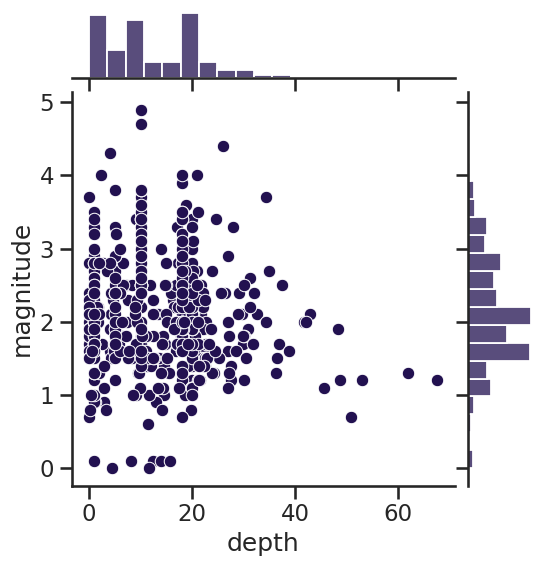

In [36]:
# bivariate plots
sns.jointplot(x='depth', y='magnitude',data=earthquake)

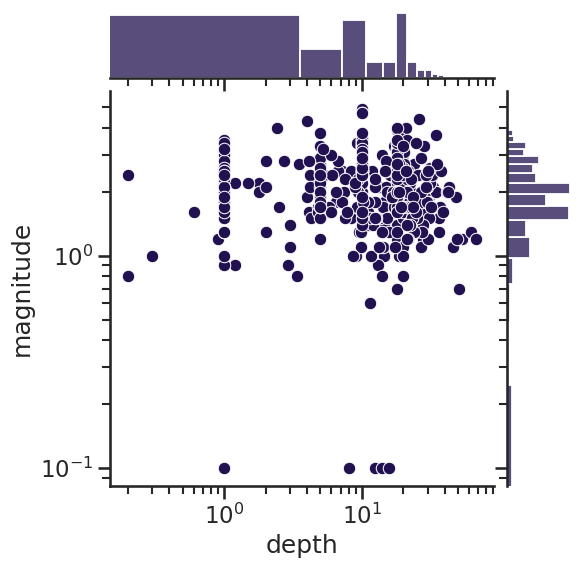

In [37]:
# bivariate plots (log-log)
sns.jointplot(x='depth',y='magnitude',data=earthquake)
plt.xscale('log')
plt.yscale('log')

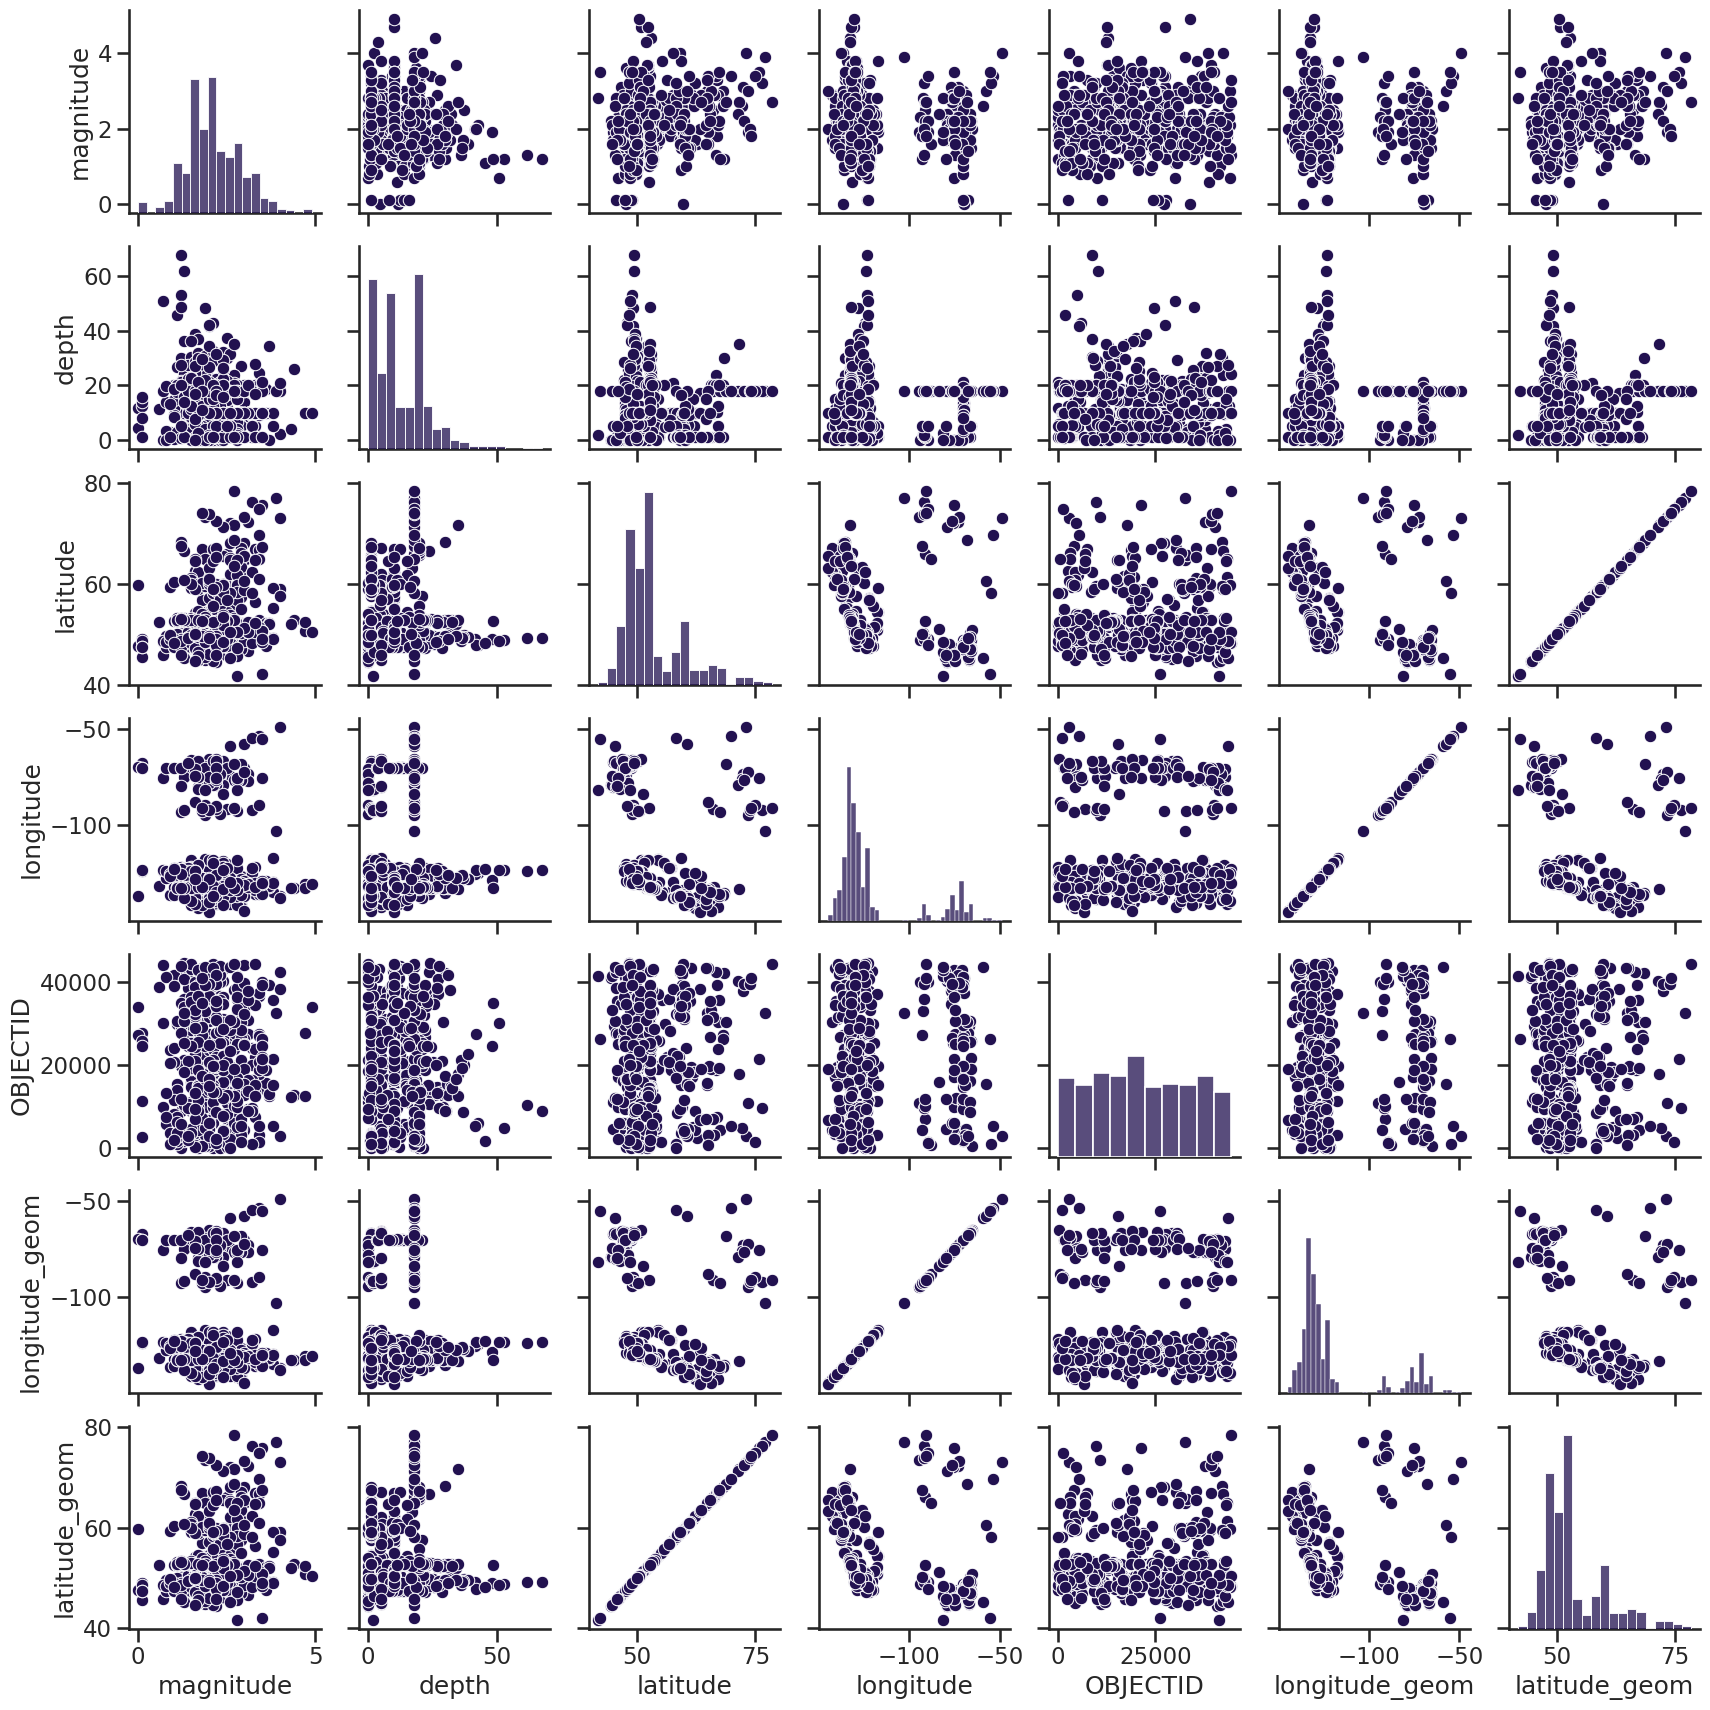

In [38]:
# pairwise plots  (time-consuming)
g=sns.pairplot(earthquake.sample(500))

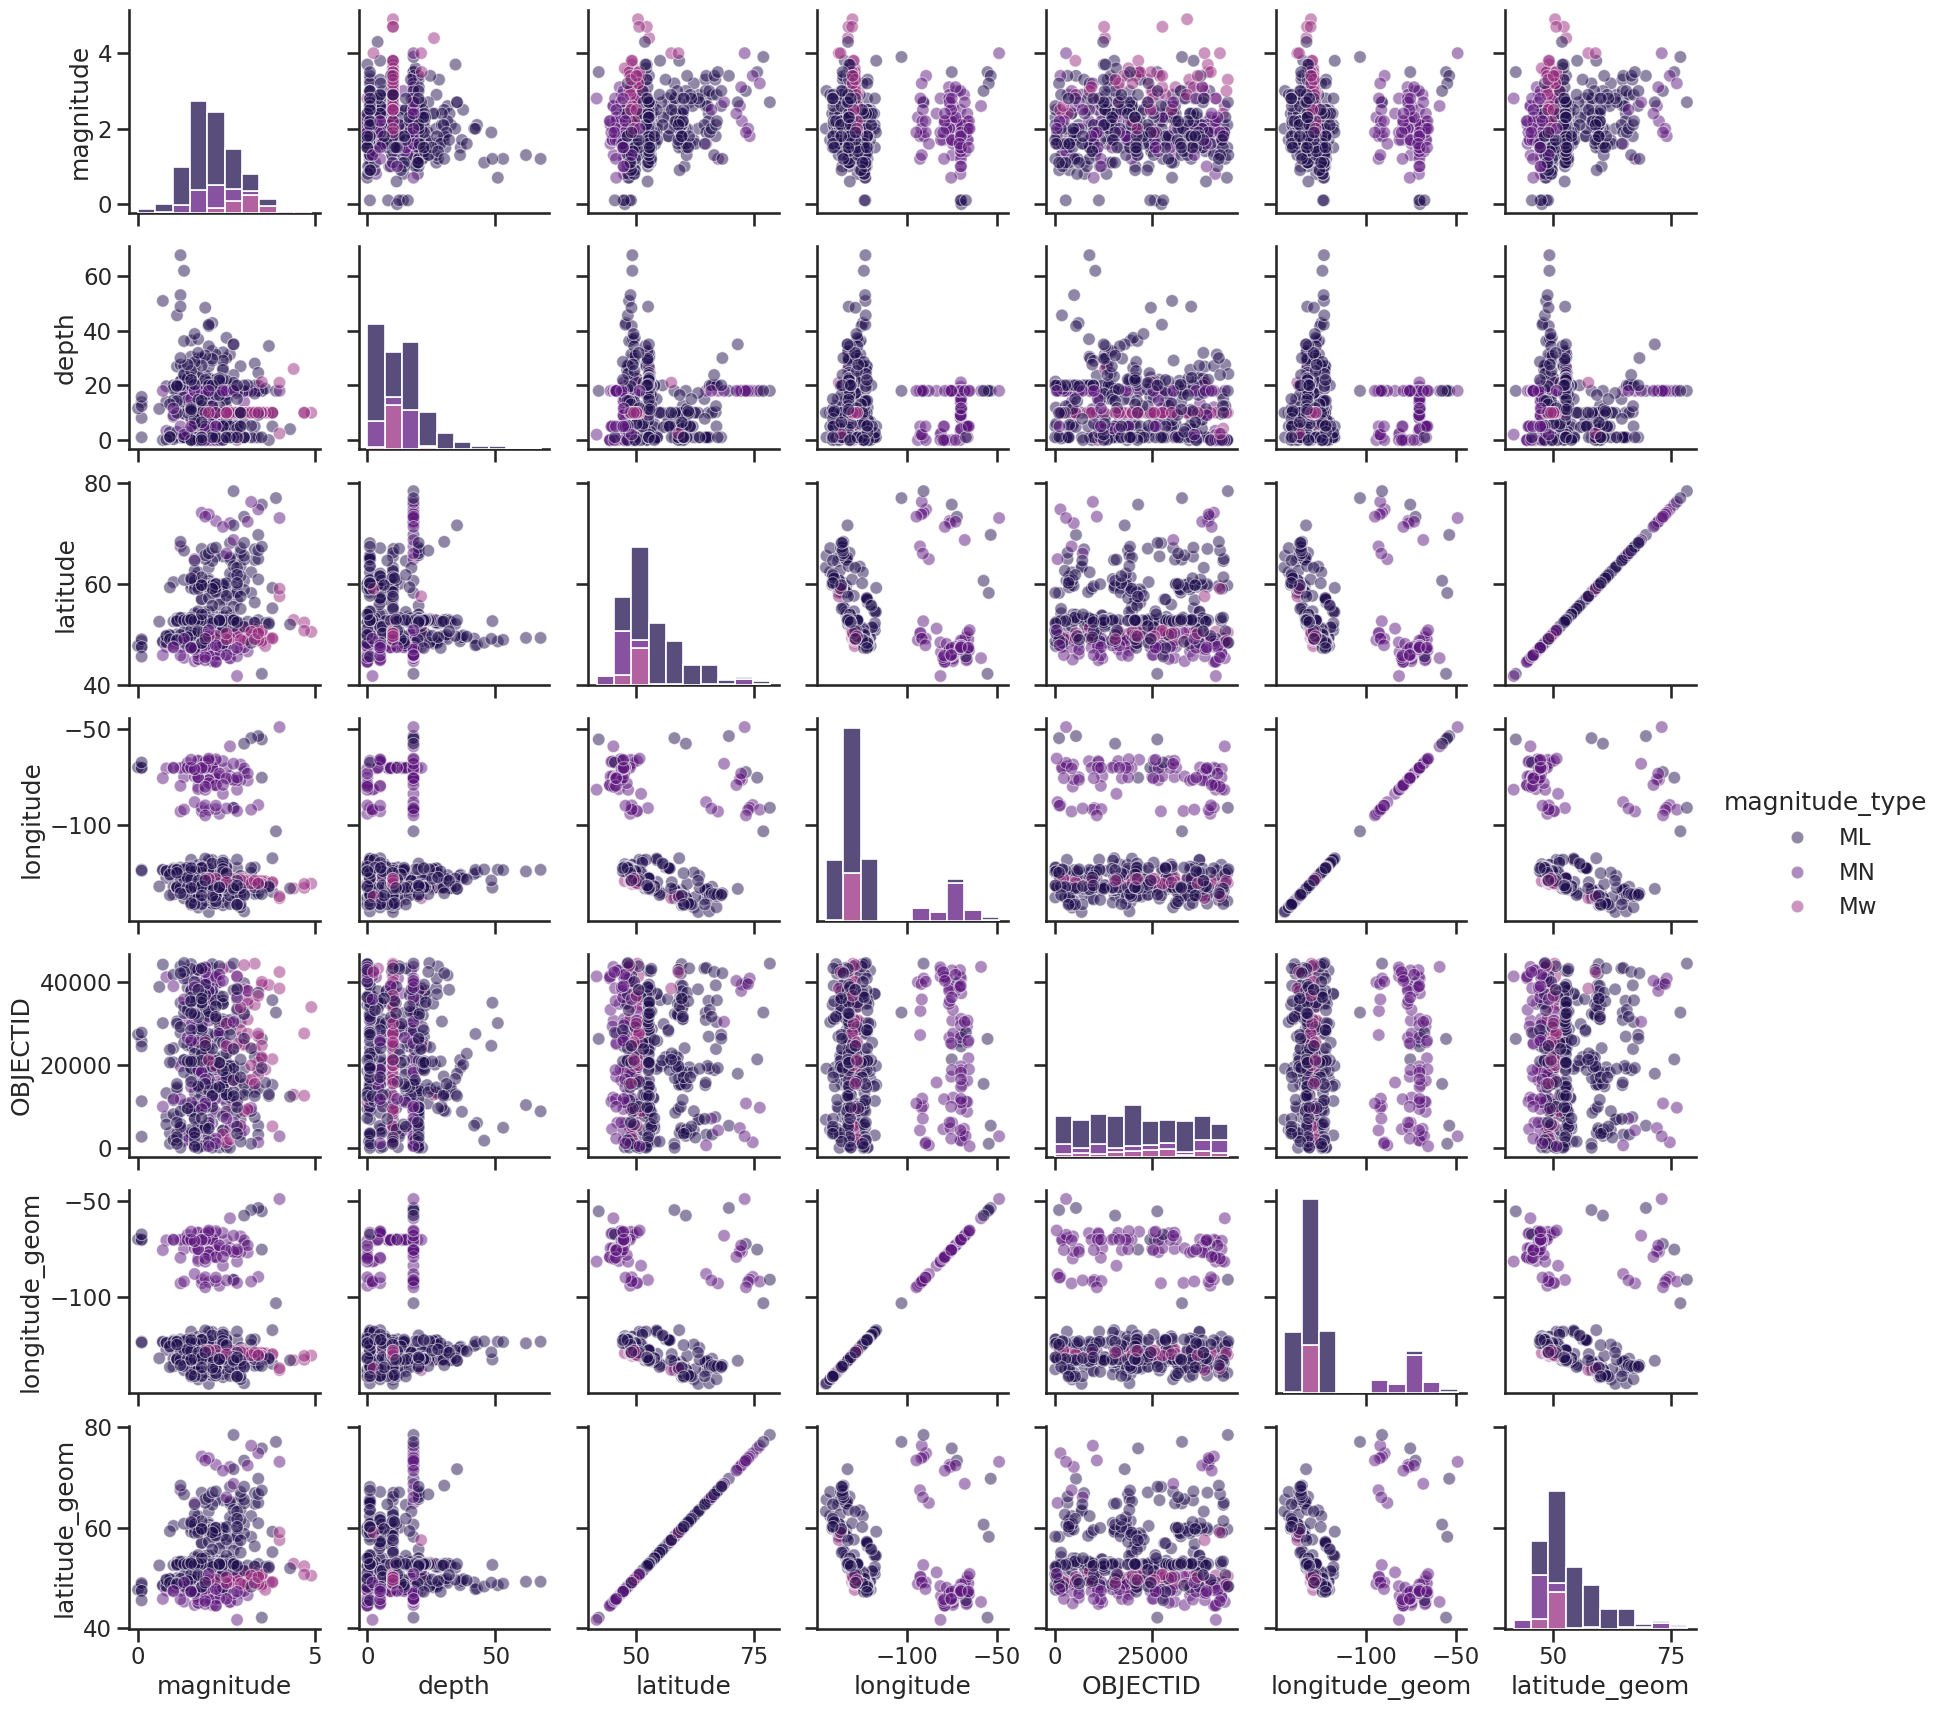

In [74]:
# another pairwise plot by group
g = sns.pairplot(earthquake.sample(500), hue='magnitude_type',
                 diag_kind='hist', diag_kws={'multiple': 'stack', 'bins': 10},
                 plot_kws={'alpha':0.5})

## In-class activity
Refer to the following figure, choose two subfigures to reproduce with the earthquake dataset.

![](../datasets/earthquake_analysis-2010-2019.png)

[Text(0.5, 1.0, 'Magnitude Distribution')]

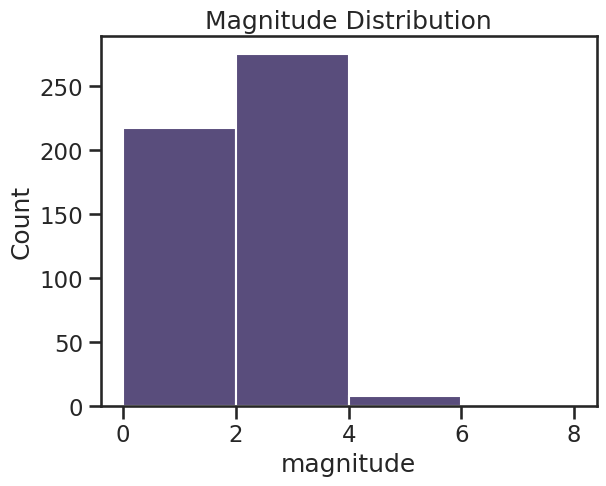

In [71]:
sns.histplot(x='magnitude',data=earthquake,bins=[0,2,4,6,8]).set(title="Magnitude Distribution")

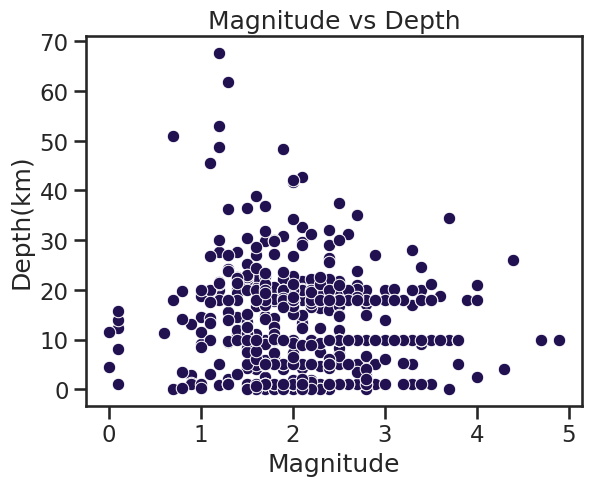

In [68]:
sns.scatterplot(data=earthquake, x="magnitude", y="depth")
plt.xlabel("Magnitude")
plt.ylabel("Depth(km)")
plt.title("Magnitude vs Depth")

plt.show()

Text(0, 0.5, 'Count')

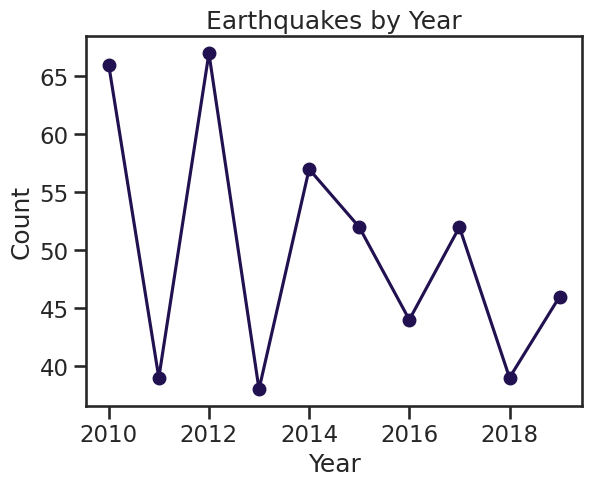

In [93]:
yearly_data = earthquake.groupby(earthquake.index.year).size()
yearly_data.plot(kind='line', marker='o', title='Earthquakes by Year')
plt.xlabel('Year')
plt.ylabel('Count')


## (In case you need this) Jupyter notebook setup

Visit https://docs.jupyter.org/en/latest/install/notebook-classic.html for some guidance to set up jupyter notebook.


---

*Note:* These notes are adapted from a blog post on [Tom's Blog](https://tomaugspurger.net/posts/modern-6-visualization/).
